In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import linregress
import scienceplots
from numpy.random import SeedSequence
# --- 定义标准高斯PDF以便求Jacobian $H_k$---
def gaussian_pdf(x):
    """Standard Gaussian PDF"""
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    else:
        return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

In [2]:
# ==========================================
# Enhanced Simulation Function (with H_k and W recording)
# ==========================================
def run_scalar_sr_simulation_full(seed_val, init_sigma, Nx_total=3000, steady_idx=1500, window_size=50):
    """
    Run simulation and record sigma, W, H_k, y_hat, and MSE metrics
    """
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    
    input_data = torch.randn(Nx_total, 1)
    N = 31
    
    # RLS parameters
    W_scalar = torch.tensor([[1.0]])
    P_rls = torch.tensor([[10.0]])
    
    # EKF parameters
    sigma_curr = init_sigma
    P_sigma = 2.0
    Q_sigma = 1e-3
    R_sigma = 1.0
    
    # Recording arrays
    sigma_history = torch.zeros(Nx_total)
    W_history = torch.zeros(Nx_total)
    H_k_history = torch.zeros(Nx_total)
    y_hat_history = torch.zeros(Nx_total)
    
    # **新增:MSE记录**
    instantaneous_mse = torch.zeros(Nx_total)  # 每个时间步的瞬时MSE
    windowed_mse = torch.zeros(Nx_total)       # 滑动窗口MSE
    
    for k in range(Nx_total):
        x_k = input_data[k, 0]
        
        # Generate noisy observations
        torch.manual_seed(seed_val + 3 * k)
        noise_vec = sigma_curr * torch.randn(N, 1)
        y_vec = torch.sign(x_k + noise_vec)
        phi_k = torch.mean(y_vec)
        
        # RLS update
        y_hat_k = W_scalar * phi_k
        e_k = x_k - y_hat_k
        
        denom = phi_k**2 * P_rls + 0.1
        g_rls = (P_rls * phi_k) / denom
        W_scalar = W_scalar + g_rls * e_k
        P_rls = P_rls - g_rls * phi_k * P_rls
        
        # EKF prediction
        sigma_pred = sigma_curr
        P_sigma_pred = P_sigma + Q_sigma
        
        # Jacobian calculation
        s_safe = max(sigma_pred, 0.01)
        u = x_k / s_safe
        pdf_val = gaussian_pdf(u)
        w_val = W_scalar.item()
        H_k = -2.0 * w_val * (x_k / (s_safe**2)) * pdf_val
        
        # EKF update
        S_innov = H_k**2 * P_sigma_pred + R_sigma
        K_sigma = P_sigma_pred * H_k / S_innov
        step = K_sigma * e_k.item()
        step = max(min(step, 0.2), -0.2)
        
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)
        P_sigma = (1 - K_sigma * H_k) * P_sigma_pred
        
        # Record all quantities
        sigma_history[k] = sigma_curr
        W_history[k] = w_val
        H_k_history[k] = H_k
        y_hat_history[k] = y_hat_k
        
        # **记录瞬时MSE (平方误差)**
        instantaneous_mse[k] = e_k.item()**2
        
        # **计算滑动窗口MSE**
        if k < window_size:
            # 窗口不足时,使用从0到k的所有数据
            windowed_mse[k] = torch.mean(instantaneous_mse[:k+1]).item()
        else:
            # 使用固定窗口大小
            windowed_mse[k] = torch.mean(instantaneous_mse[k-window_size+1:k+1]).item()
        
        sigma_curr = sigma_new
    
    # **计算稳态后的各种MSE指标**
    final_sigma = torch.mean(sigma_history[steady_idx:]).item()
    
    # 方法1: 稳态后的平均MSE (与你的final_mse一致)
    final_mse = torch.mean((input_data[steady_idx:, 0] - y_hat_history[steady_idx:])**2).item()
    
    # 方法2: 稳态后的瞬时MSE的平均值 (应该与方法1相同)
    final_mse_alt = torch.mean(instantaneous_mse[steady_idx:]).item()
    
    # 方法3: 稳态后的滑动窗口MSE的平均值
    final_windowed_mse = torch.mean(windowed_mse[steady_idx:]).item()
    
    return {
        'sigma_history': sigma_history,
        'W_history': W_history,
        'H_k_history': H_k_history,
        'y_hat_history': y_hat_history,
        'instantaneous_mse': instantaneous_mse,      # 每个时间步的MSE
        'windowed_mse': windowed_mse,                # 滑动平均MSE
        'final_sigma': final_sigma,
        'final_mse': final_mse,                      # 稳态MSE
        'final_mse_alt': final_mse_alt,              # 验证用
        'final_windowed_mse': final_windowed_mse     # 稳态滑动MSE
    }
# ==========================================
# Experimental Setup
# ==========================================
print("\n" + "="*80)
print("5-Panel Analysis: Sigma, W, H_k, and MSE Convergence Trajectories")
print("Showing COMPLETE convergence process from iteration 0")
print("="*80)

init_values = [0.1, 0.5, 1.5, 4.0]
num_trials = 20
base_seed = 451
Nx_total = 3000
steady_idx = 1500
window_size = 50  # 滑动窗口大小

# Storage for all trajectories
all_results = {init_val: {
    'sigma_trajs': [],
    'W_trajs': [],
    'H_k_trajs': [],
    'instantaneous_mse_trajs': [],   # 新增: 瞬时MSE轨迹
    'windowed_mse_trajs': [],        # 新增: 滑动MSE轨迹
    'final_sigmas': [],
    'final_mses': [],
    'final_windowed_mses': [],       # 新增: 稳态滑动MSE
    'convergence_times': []          # 新增: 收敛时间
} for init_val in init_values}

# Run experiments
print(f"\nRunning {num_trials} trials for each initial value...")
for init_val in init_values:
    print(f"  Processing Init_Sigma = {init_val}...")
    for trial in range(num_trials):
        seed = base_seed + trial
        
        # 调用修改后的函数
        results = run_scalar_sr_simulation_full(
            seed, init_val, Nx_total, steady_idx, window_size
        )
        
        # 存储所有轨迹
        all_results[init_val]['sigma_trajs'].append(results['sigma_history'].numpy())
        all_results[init_val]['W_trajs'].append(results['W_history'].numpy())
        all_results[init_val]['H_k_trajs'].append(results['H_k_history'].numpy())
        all_results[init_val]['instantaneous_mse_trajs'].append(results['instantaneous_mse'].numpy())
        all_results[init_val]['windowed_mse_trajs'].append(results['windowed_mse'].numpy())
        
        # 存储最终性能指标
        all_results[init_val]['final_sigmas'].append(results['final_sigma'])
        all_results[init_val]['final_mses'].append(results['final_mse'])
        all_results[init_val]['final_windowed_mses'].append(results['final_windowed_mse'])
        
        # 计算收敛时间 (滑动MSE首次低于稳态值的110%)
        threshold = results['final_mse'] * 1.1
        converge_idx = np.where(results['windowed_mse'].numpy() < threshold)[0]
        if len(converge_idx) > 0:
            all_results[init_val]['convergence_times'].append(converge_idx[0])
        else:
            all_results[init_val]['convergence_times'].append(Nx_total)  # 未收敛

print("\nCalculating statistics across trials...")

# Calculate statistics
for init_val in init_values:
    # 转换为numpy数组
    all_results[init_val]['sigma_trajs'] = np.array(all_results[init_val]['sigma_trajs'])
    all_results[init_val]['W_trajs'] = np.array(all_results[init_val]['W_trajs'])
    all_results[init_val]['H_k_trajs'] = np.array(all_results[init_val]['H_k_trajs'])
    all_results[init_val]['instantaneous_mse_trajs'] = np.array(all_results[init_val]['instantaneous_mse_trajs'])
    all_results[init_val]['windowed_mse_trajs'] = np.array(all_results[init_val]['windowed_mse_trajs'])
    
    # 计算均值和标准差
    all_results[init_val]['sigma_mean'] = np.mean(all_results[init_val]['sigma_trajs'], axis=0)
    all_results[init_val]['sigma_std'] = np.std(all_results[init_val]['sigma_trajs'], axis=0)
    
    all_results[init_val]['W_mean'] = np.mean(all_results[init_val]['W_trajs'], axis=0)
    all_results[init_val]['W_std'] = np.std(all_results[init_val]['W_trajs'], axis=0)
    
    all_results[init_val]['H_k_mean'] = np.mean(all_results[init_val]['H_k_trajs'], axis=0)
    all_results[init_val]['H_k_std'] = np.std(all_results[init_val]['H_k_trajs'], axis=0)
    
    # MSE统计
    all_results[init_val]['inst_mse_mean'] = np.mean(all_results[init_val]['instantaneous_mse_trajs'], axis=0)
    all_results[init_val]['inst_mse_std'] = np.std(all_results[init_val]['instantaneous_mse_trajs'], axis=0)
    
    all_results[init_val]['win_mse_mean'] = np.mean(all_results[init_val]['windowed_mse_trajs'], axis=0)
    all_results[init_val]['win_mse_std'] = np.std(all_results[init_val]['windowed_mse_trajs'], axis=0)

# ==========================================
# Print Summary Statistics
# ==========================================
print("\n" + "="*80)
print("CONVERGENCE PERFORMANCE SUMMARY")
print("="*80)
print(f"{'Init σ':<10} {'Final σ':<20} {'Final W':<20} {'Final MSE':<20} {'Conv. Time':<15}")
print("-"*80)

for init_val in init_values:
    final_sigma_mean = np.mean(all_results[init_val]['final_sigmas'])
    final_sigma_std = np.std(all_results[init_val]['final_sigmas'])
    
    final_W_mean = all_results[init_val]['W_mean'][-1]
    final_W_std = all_results[init_val]['W_std'][-1]
    
    final_mse_mean = np.mean(all_results[init_val]['final_mses'])
    final_mse_std = np.std(all_results[init_val]['final_mses'])
    
    conv_time_mean = np.mean(all_results[init_val]['convergence_times'])
    conv_time_std = np.std(all_results[init_val]['convergence_times'])
    
    print(f"{init_val:<10.1f} "
          f"{final_sigma_mean:>6.4f}±{final_sigma_std:<5.4f}    "
          f"{final_W_mean:>6.4f}±{final_W_std:<5.4f}    "
          f"{final_mse_mean:>6.4f}±{final_mse_std:<5.4f}    "
          f"{conv_time_mean:>6.0f}±{conv_time_std:<5.0f}")

print("\n" + "="*80)
print("DETAILED STATISTICS BY INITIAL VALUE")
print("="*80)

for init_val in init_values:
    print(f"\n{'─'*80}")
    print(f"Init Sigma = {init_val}")
    print(f"{'─'*80}")
    
    print(f"  Final Sigma:        {np.mean(all_results[init_val]['final_sigmas']):.4f} ± "
          f"{np.std(all_results[init_val]['final_sigmas']):.4f}")
    
    print(f"  Final W:            {all_results[init_val]['W_mean'][-1]:.4f} ± "
          f"{all_results[init_val]['W_std'][-1]:.4f}")
    
    print(f"  Final H_k:          {all_results[init_val]['H_k_mean'][-1]:.6f} ± "
          f"{all_results[init_val]['H_k_std'][-1]:.6f}")
    
    print(f"  Final MSE:          {np.mean(all_results[init_val]['final_mses']):.6f} ± "
          f"{np.std(all_results[init_val]['final_mses']):.6f}")
    
    print(f"  Final Windowed MSE: {np.mean(all_results[init_val]['final_windowed_mses']):.6f} ± "
          f"{np.std(all_results[init_val]['final_windowed_mses']):.6f}")
    
    print(f"  Convergence Time:   {np.mean(all_results[init_val]['convergence_times']):.0f} ± "
          f"{np.std(all_results[init_val]['convergence_times']):.0f} steps")
    
    # 初始MSE (前100步)
    init_mse = np.mean(all_results[init_val]['win_mse_mean'][:100])
    final_mse = np.mean(all_results[init_val]['final_mses'])
    improvement = init_mse / final_mse if final_mse > 0 else float('inf')
    
    print(f"  Initial MSE (0-100): {init_mse:.6f}")
    print(f"  MSE Improvement:     {improvement:.2f}x")

print("\n" + "="*80)

# ==========================================
# Comparison Table
# ==========================================
print("\n" + "="*80)
print("ALGORITHM ROBUSTNESS ANALYSIS")
print("="*80)

# 找出最快和最慢收敛的初始值
conv_times = {init_val: np.mean(all_results[init_val]['convergence_times']) 
              for init_val in init_values}
fastest_init = min(conv_times, key=conv_times.get)
slowest_init = max(conv_times, key=conv_times.get)

print(f"\nFastest Convergence: Init_σ = {fastest_init} ({conv_times[fastest_init]:.0f} steps)")
print(f"Slowest Convergence: Init_σ = {slowest_init} ({conv_times[slowest_init]:.0f} steps)")
print(f"Convergence Ratio:   {conv_times[slowest_init]/conv_times[fastest_init]:.2f}x")

# MSE性能比较
final_mses = {init_val: np.mean(all_results[init_val]['final_mses']) 
              for init_val in init_values}
best_mse_init = min(final_mses, key=final_mses.get)
worst_mse_init = max(final_mses, key=final_mses.get)

print(f"\nBest Final MSE:      Init_σ = {best_mse_init} (MSE = {final_mses[best_mse_init]:.6f})")
print(f"Worst Final MSE:     Init_σ = {worst_mse_init} (MSE = {final_mses[worst_mse_init]:.6f})")
print(f"MSE Variance:        {np.std(list(final_mses.values())):.6f}")

print("\n" + "="*80 + "\n")


5-Panel Analysis: Sigma, W, H_k, and MSE Convergence Trajectories
Showing COMPLETE convergence process from iteration 0

Running 20 trials for each initial value...
  Processing Init_Sigma = 0.1...
  Processing Init_Sigma = 0.5...
  Processing Init_Sigma = 1.5...
  Processing Init_Sigma = 4.0...

Calculating statistics across trials...

CONVERGENCE PERFORMANCE SUMMARY
Init σ     Final σ              Final W              Final MSE            Conv. Time     
--------------------------------------------------------------------------------
0.1        0.9711±0.0283    1.5213±0.0338    0.1049±0.0076        43±59   
0.5        1.0307±0.0315    1.5893±0.0373    0.1036±0.0075        12±30   
1.5        1.1330±0.0361    1.7035±0.0422    0.1051±0.0073        30±52   
4.0        1.2807±0.0408    1.8599±0.0409    0.1138±0.0076       125±128  

DETAILED STATISTICS BY INITIAL VALUE

────────────────────────────────────────────────────────────────────────────────
Init Sigma = 0.1
────────────────────

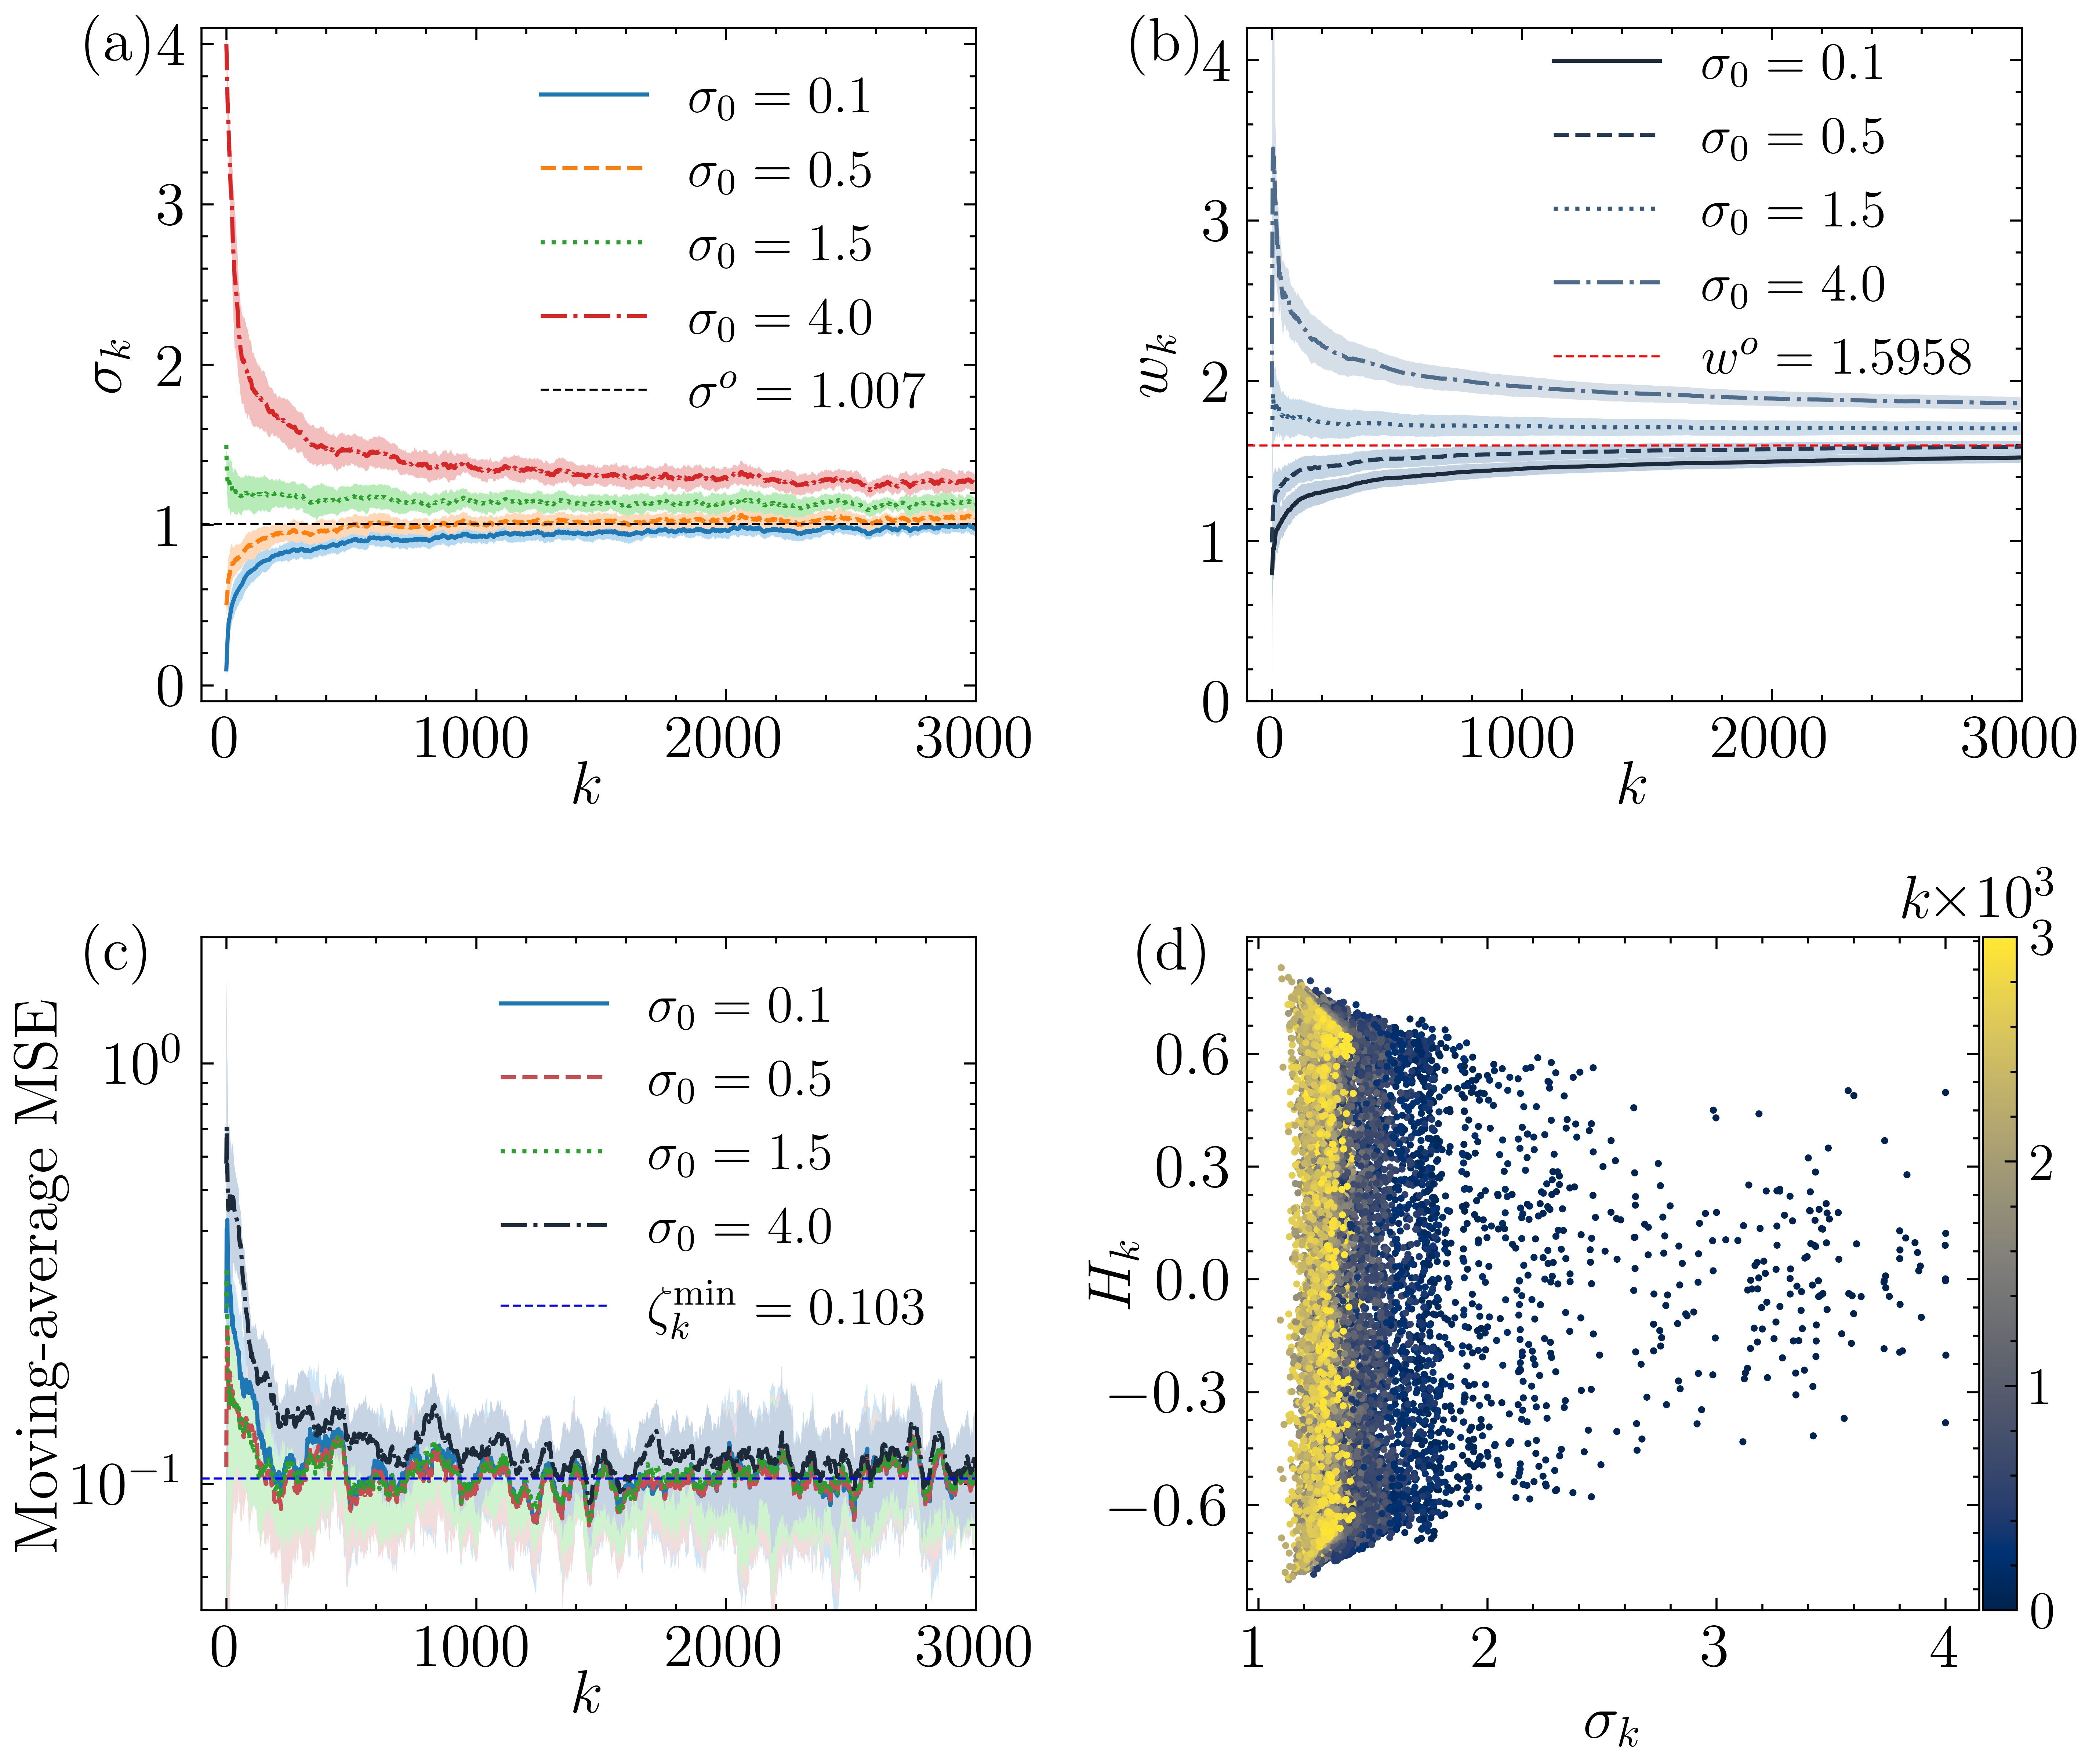

In [6]:
##### --- 绘图风格设置 ---
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import colorsys

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',   # 数学公式风格接近 Times
    'font.size': 15,
    'axes.labelsize': 15,
    'legend.fontsize': 15,
})

def lighten_color(color, amount=0.7):
    """
    Lightens the given color by mixing with white
    amount=0 returns white, amount=1 returns original color
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# ==========================================
# Create EPS-Compatible Figure with adjusted spacing
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
# 调整子图间距，增加水平间距以避免ylabel遮挡
plt.subplots_adjust(hspace=0.35, wspace=0.35)

axes = axes.flatten()
labels_txt = ['(a)', '(b)', '(c)', '(d)']

# Define colors for different panels - 三个面板使用不同色系
# Panel 1 (sigma): 经典色系 - 蓝橙绿红
colors_panel1 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
light_colors_panel1 = [lighten_color(c, amount=0.3) for c in colors_panel1]

# Panel 2 (MSE): 极清晰对比（偏硬朗）
colors_panel2 = [
    '#1f77b4',  # strong blue
    '#c44e52',  # muted red (not pink)
    '#2ca02c',  # strong green
    '#1c2a39'   # dark gray 
]
light_colors_panel2 = [lighten_color(c, amount=0.20) for c in colors_panel2]

# Panel 3 (W): 灰蓝色系（极其稳重）
colors_panel3 = [
    '#1c2a39',  # near-black blue
    '#243b53',  # deep steel blue
    '#355c7d',  # strong slate blue
    '#4f6d8a'   # lighter blue-gray
]
light_colors_panel3 = [lighten_color(c, amount=0.22) for c in colors_panel3]

iterations = np.arange(Nx_total)

# ==========================================
# Figure 1A: Sigma Convergence - Use LIGHT colors for shading
# ==========================================
ax1a = axes[0]
for i, init_val in enumerate(init_values):
    mean_traj = all_results[init_val]['sigma_mean']
    std_traj = all_results[init_val]['sigma_std']
    
    # Plot shaded region FIRST with light color (NO alpha)
    ax1a.fill_between(iterations, mean_traj - std_traj, mean_traj + std_traj,
                      color=light_colors_panel1[i], edgecolor='none')
    
    # Plot mean line on top with dark color
    ax1a.plot(iterations, mean_traj, color=colors_panel1[i], linewidth=1.0, 
             label=f'$\sigma_0 = {init_val}$')
ax1a.axhline(y=1.007, color='k', linestyle=(0, (4, 2)), linewidth=0.5,
             label=r'$\sigma^o = 1.007$')
ax1a.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax1a.set_ylim(-0.1, 4.1)
ax1a.set_xlabel(r'$k$', labelpad=-2)
ax1a.set_ylabel(r'$\sigma_k$',labelpad=6)
ax1a.set_yticks([0, 1, 2, 3, 4])
ax1a.set_xlim(-100, Nx_total)
ax1a.text(-0.15, 1.02, labels_txt[0], transform=ax1a.transAxes,
         fontsize=15, va='top')

# ==========================================
# Panel 2: Windowed MSE Convergence Trajectories
# 使用虚线与Panel 1区分
# ==========================================
ax2 = axes[2]

for i, init_val in enumerate(init_values):
    mean_traj = all_results[init_val]['win_mse_mean']
    std_traj = all_results[init_val]['win_mse_std']
    
    # Shaded region with light color (NO alpha parameter)
    ax2.fill_between(iterations, 
                     np.maximum(mean_traj - std_traj, 1e-5),  # 避免log(0)
                     mean_traj + std_traj,
                     color=light_colors_panel2[i], edgecolor='none')
    
    # Mean line with dark color
    ax2.plot(iterations, mean_traj, color=colors_panel2[i], 
             linewidth=1.0, 
             label=f'$\sigma_0 = {init_val}$')

# 添加稳态MSE参考线
avg_steady_mse = np.mean([np.mean(all_results[iv]['final_mses']) for iv in init_values])
ax2.axhline(y=0.103, color='blue', linestyle=(0, (4, 2)), linewidth=0.5, 
            zorder=10, label=r'$\zeta_k^{\rm min} = 0.103$')
ax2.set_yscale('log')  # 对数坐标展示收敛
ax2.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax2.set_xlabel(r'$k$', labelpad=-2)
# 缩短ylabel避免遮挡，或者增加labelpad
ax2.set_ylabel(r'Moving-average MSE', labelpad=1) 
ax2.set_xlim(-100, Nx_total)
ax2.set_ylim(bottom=5e-2, top=2e0)
ax2.text(-0.15, 1.02, labels_txt[2], transform=ax2.transAxes,
         fontsize=15, va='top')

# ==========================================
# Panel 3: W convergence - 使用点划线进一步区分
# ==========================================
ax3 = axes[1]

for i, init_val in enumerate(init_values):
    mean_traj = all_results[init_val]['W_mean']
    std_traj = all_results[init_val]['W_std']
    
    # Shaded region with light color (NO alpha parameter)
    ax3.fill_between(iterations, 
                     np.maximum(mean_traj - std_traj, 1e-5),  # 避免log(0)
                     mean_traj + std_traj,
                     color=light_colors_panel3[i], edgecolor='none')
    
    # Mean line with dark color
    ax3.plot(iterations, mean_traj, color=colors_panel3[i], 
             linewidth=1.0,
             label=f'$\sigma_0 = {init_val}$')
ax3.axhline(y=1.5958, color='red', linestyle=(0, (4, 2)), linewidth=0.5,
            label=r'$w^o = 1.5958$')
ax3.legend(loc='upper right',
           bbox_to_anchor=(1.0, 1.05),  # 向上移动
           fontsize=13,
           framealpha=0.9)

ax3.set_xlabel(r'$k$', labelpad=-2)
ax3.set_ylabel(r'$w_k$',labelpad=6)
ax3.set_ylim(0, 4.2)
ax3.set_xlim(-100, Nx_total)
ax3.text(-0.15, 1.02, labels_txt[1], transform=ax3.transAxes,
         fontsize=15, va='top')

# ==========================================
# Figure 4: H_k Scatter for Init_Sigma = 4.0
# ==========================================
ax4 = axes[3]
init_val_plot = 4.0

all_sigma = []
all_H_k = []
all_iter = []

for trial_idx in range(min(5, num_trials)):
    H_k_sample = all_results[init_val_plot]['H_k_trajs'][trial_idx, :]
    sigma_sample = all_results[init_val_plot]['sigma_trajs'][trial_idx, :]
    all_sigma.extend(sigma_sample)
    all_H_k.extend(H_k_sample)
    all_iter.extend(iterations)

scatter = ax4.scatter(all_sigma, all_H_k, c=all_iter, cmap='cividis',
                     s=3, edgecolors='none', rasterized=True)

cbar = plt.colorbar(scatter, ax=ax4, pad=0.005, fraction=0.05)
cbar.set_ticks([0.0, 1000, 2000, 3000])
cbar.set_ticklabels([r'$0.0$', r'$1.0$', r'$2.0$', r'$3.0$'])
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
cbar.formatter = formatter
cbar.update_ticks()
cbar.ax.tick_params(labelsize=13)
cbar.ax.text(
    -2.4, 1.01, r'$k$',
    transform=cbar.ax.transAxes,
    fontsize=15,
    ha='left',
    va='bottom'
)
offset_text = cbar.ax.yaxis.get_offset_text()
offset_text.set_x(0.5)
offset_text.set_y(1.02)
offset_text.set_ha('center')
offset_text.set_va('bottom')

#ax4.axhline(y=0, color='red', linestyle='--', linewidth=1.0)
ax4.set_xlabel(r'$\sigma_k$')
ax4.set_ylabel(r'$H_k$', labelpad=-8)
ax4.set_xticks([1,2,3,4])
ax4.set_yticks([-0.6,-0.3,0,0.3,0.6])
ax4.text(-0.15, 1.02, labels_txt[3], transform=ax4.transAxes,
         fontsize=15, va='top')

# 保存为EPS格式
fig.savefig(
    'D:/IEEE 2025 Adaptive weighted SSR/Fig.eps',
    format='eps',
    dpi=800,
    bbox_inches='tight'
)

plt.show()